# 04. ML - stratified cross-validation

This is the only live ML notebook for the one-bioproject workshop.

Minimal ML pipeline:
1. keep target disease and healthy controls;
2. split by stratified CV;
3. select features inside each training fold only;
4. apply CLR transformation;
5. scale features;
6. tune ridge logistic regression;
7. plot ROC curves;
8. report AUC, MCC and balanced accuracy.

In [1]:
from pathlib import Path

# Main paths. Usually only this cell needs editing.
PROJECT_DIR = Path(".").resolve()
DATA_DIR = PROJECT_DIR / "data"
OUT_DIR = PROJECT_DIR / "outputs_minimal"

TAX_PATH = DATA_DIR / "tax.csv"
PATHWAY_PATH = DATA_DIR / "path.csv"
METADATA_PATH = DATA_DIR / "metadata.csv"

FIG_DIR = OUT_DIR / "figures"
RESULTS_DIR = OUT_DIR / "results"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("TAX:", TAX_PATH)
print("PATH:", PATHWAY_PATH)
print("METADATA:", METADATA_PATH)
print("OUT:", OUT_DIR)

TAX: /srv/common/seraph/workshop/code/data/tax.csv
PATH: /srv/common/seraph/workshop/code/data/path.csv
METADATA: /srv/common/seraph/workshop/code/data/metadata.csv
OUT: /srv/common/seraph/workshop/code/outputs_minimal


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve
from sklearn.model_selection import StratifiedKFold

from simple_utils import (
    classification_metrics,
    fit_logistic_regression,
    load_data,
    make_target,
    prepare_train_test,
    summarize_metrics,
)

In [3]:
TARGET = "K05"       # "K05" or "K02"
FEATURE_SET = "TAX" # "TAX", "PATH" or "TAX+PATH"
N_SPLITS = 5
RANDOM_STATE = 42

bundle = load_data(TAX_PATH, PATHWAY_PATH, METADATA_PATH)
y, meta_task = make_target(bundle.meta, TARGET)
y_by_run = pd.Series(y, index=meta_task.index, name=TARGET)

n_pos = int(y_by_run.sum())
n_neg = int((y_by_run == 0).sum())
n_splits_used = min(N_SPLITS, n_pos, n_neg)
if n_splits_used < 2:
    raise ValueError("Need at least 2 positive and 2 healthy samples for CV")

print("Target:", TARGET)
print("Feature set:", FEATURE_SET)
print("Samples:", len(meta_task))
print("Positive:", n_pos)
print("Healthy:", n_neg)
print("Bioprojects:", meta_task["bioproject"].nunique())
print("CV splits:", n_splits_used)

Target: K05
Feature set: TAX
Samples: 151
Positive: 87
Healthy: 64
Bioprojects: 1
CV splits: 5


In [4]:
rows = []
roc_rows = []
cv = StratifiedKFold(n_splits=n_splits_used, shuffle=True, random_state=RANDOM_STATE)
runs = meta_task.index.to_numpy()

for fold, (train_idx, test_idx) in enumerate(cv.split(runs, y), start=1):
    train_runs = runs[train_idx]
    test_runs = runs[test_idx]
    y_train = y_by_run.loc[train_runs].to_numpy(dtype=int)
    y_test = y_by_run.loc[test_runs].to_numpy(dtype=int)

    if len(set(y_train)) < 2 or len(set(y_test)) < 2:
        rows.append({"fold": fold, "status": "skip_single_class"})
        continue

    try:
        x_train, x_test, features = prepare_train_test(
            bundle=bundle,
            train_runs=train_runs,
            test_runs=test_runs,
            feature_set=FEATURE_SET,
        )
    except ValueError as exc:
        rows.append({"fold": fold, "status": "skip_no_features", "error": str(exc)})
        continue

    model, best_params = fit_logistic_regression(x_train, y_train, random_state=RANDOM_STATE)
    probability = model.predict_proba(x_test)[:, 1]
    metrics = classification_metrics(y_test, probability)

    rows.append({
        "fold": fold,
        "status": "ok",
        "target": TARGET,
        "feature_set": FEATURE_SET,
        "n_train": len(train_runs),
        "n_test": len(test_runs),
        "n_pos_train": int(y_train.sum()),
        "n_pos_test": int(y_test.sum()),
        "n_features": len(features),
        "best_C": best_params.get("C"),
        **metrics,
    })

    fpr, tpr, thresholds = roc_curve(y_test, probability)
    for x, yy, threshold in zip(fpr, tpr, thresholds):
        roc_rows.append({
            "fold": fold,
            "fpr": x,
            "tpr": yy,
            "threshold": threshold,
            "AUC": metrics["AUC"],
        })

cv_results = pd.DataFrame(rows)
roc_df = pd.DataFrame(roc_rows)

cv_results.to_csv(RESULTS_DIR / f"ml_cv_{TARGET}_{FEATURE_SET}.csv", index=False)
roc_df.to_csv(RESULTS_DIR / f"ml_cv_roc_{TARGET}_{FEATURE_SET}.csv", index=False)

cv_results

/home/jupyter-seraph/.conda/envs/pyEDA_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/jupyter-seraph/.conda/envs/pyEDA_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/jupyter-seraph/.conda/envs/pyEDA_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was depreca

,fold,status,target,feature_set,n_train,n_test,n_pos_train,n_pos_test,n_features,best_C,AUC,MCC,BACC
0,1,ok,K05,TAX,120,31,69,18,595,0.01,0.876068,0.543557,0.750000
1,2,ok,K05,TAX,121,30,69,18,595,0.01,0.824074,0.600099,0.805556
2,3,ok,K05,TAX,121,30,70,17,594,0.01,0.687783,0.336336,0.669683
3,4,ok,K05,TAX,121,30,70,17,593,0.01,0.764706,0.386197,0.687783
4,5,ok,K05,TAX,121,30,70,17,586,0.01,0.742081,0.278658,0.640271


In [5]:
cv_summary = summarize_metrics(cv_results)
cv_summary.to_csv(RESULTS_DIR / f"ml_cv_summary_{TARGET}_{FEATURE_SET}.csv", index=False)
cv_summary

,n_splits,mean_AUC,sd_AUC,mean_MCC,sd_MCC,mean_BACC,sd_BACC
0,5,0.778943,0.073044,0.42897,0.137313,0.710659,0.066539


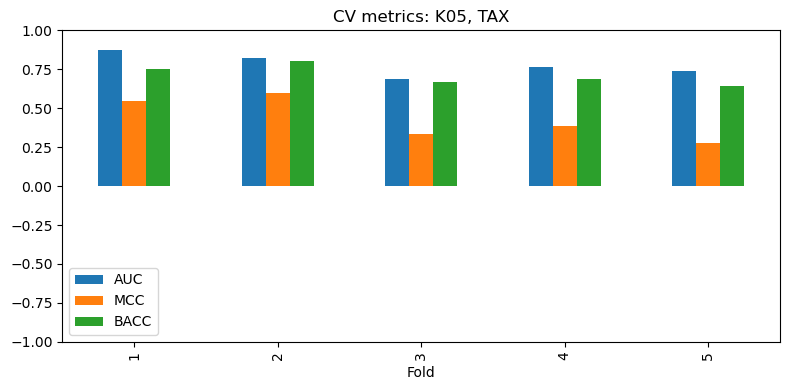

In [6]:
metric_cols = ["AUC", "MCC", "BACC"]
ok = cv_results[cv_results["status"] == "ok"].copy()

if ok.empty:
    print("No successful CV folds. Check class counts and input tables.")
elif not set(metric_cols).issubset(ok.columns):
    print("No metric columns found. Results table:")
    display(cv_results)
else:
    plot_df = ok.set_index("fold")[metric_cols]
    ax = plot_df.plot(kind="bar", figsize=(8, 4))
    ax.set_title(f"CV metrics: {TARGET}, {FEATURE_SET}")
    ax.set_xlabel("Fold")
    ax.set_ylim(-1, 1)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"ml_cv_metrics_{TARGET}_{FEATURE_SET}.png", dpi=200)
    plt.show()

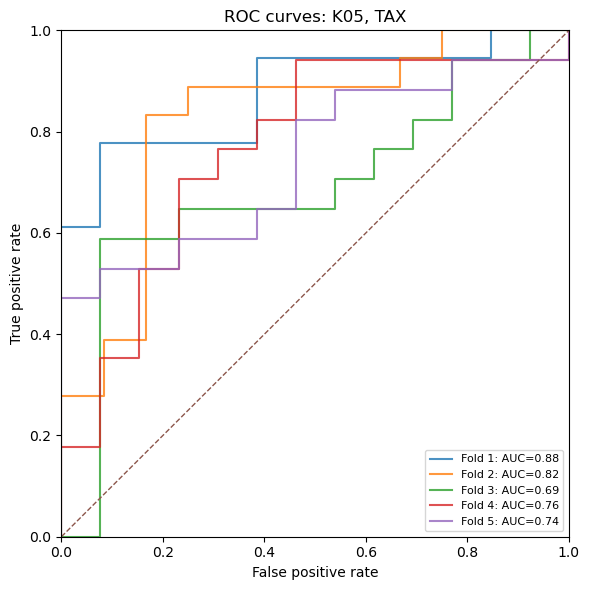

In [7]:
if roc_df.empty:
    print("No ROC curves to plot.")
else:
    fig, ax = plt.subplots(figsize=(6, 6))

    for fold, part in roc_df.groupby("fold"):
        auc_value = part["AUC"].iloc[0]
        ax.plot(part["fpr"], part["tpr"], alpha=0.8, label=f"Fold {fold}: AUC={auc_value:.2f}")

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title(f"ROC curves: {TARGET}, {FEATURE_SET}")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"ml_cv_roc_{TARGET}_{FEATURE_SET}.png", dpi=200)
    plt.show()